# 06 — Opening the sealed half, and writing it down

Notebook 03 split the real catalogues in two and sealed one half. Notebooks 03, 04 and 05 used
only `dev`: the failure was measured there, the mechanism was diagnosed there, the feature set
was chosen there by reading real-sky recall off a table.

That last step is what makes the `dev` numbers untrustworthy as a final report. Choosing between
eight feature sets by looking at Cepheid recall makes Cepheid recall a training signal. It is a
mild form of overfitting, but it is overfitting, and the only clean way to remove it is to have
put half the data beyond reach before starting.

This notebook:

1. Restates exactly what was decided where, so the reader can audit the claim.
2. Chooses the operating point — **on `dev`**, because a threshold is a decision like any other.
3. **Opens `lock`** and reports the headline numbers, once.
4. Asks which stars still fail, and whether that is the model's fault or the catalogue's.
5. Writes the model card.

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy import optimize, stats

import lmc
from lmc import models
from lmc.metrics import fmt_recall, wilson_ci
from lmc.split import SEED

OUT = Path("../outputs/v2_robust")
CEPH_C, RRL_C, MW_C, LMC_C = "#2ec4b6", "#9b5de5", "#6b8cae", "#ff8c42"

sim = lmc.load_sim(verbose=True)
real = pl.read_parquet("../data/processed/real_lmc.parquet")
simL = sim.filter(pl.col("Type") == 1)

model_dir, clf, FEATURES = models.load("v2_robust")
calibrator = joblib.load(OUT / "calibrator.joblib")
pm_ref = json.loads((OUT / "pm_reference.json").read_text())

y = sim["Type"].to_numpy()
_, test_idx = lmc.load_split(OUT / "split.npz", y)     # verifies the label hash

scoreable = pl.col("astrometry_ok") & pl.col("photometry_ok")
dev = real.filter((pl.col("split") == "dev") & scoreable)
lock = real.filter((pl.col("split") == "lock") & scoreable)

def P(frame):
    raw = clf.predict_proba(frame.select(FEATURES).to_numpy().astype(np.float32))[:, 1]
    return calibrator.predict(raw)

print(f"model    {model_dir.name}   features {FEATURES}")
print(f"dev      {dev.height:,} stars   (used for every decision)")
print(f"lock     {lock.height:,} stars   (untouched until section 3)")

  loaded 1,269,704 rows from data/processed/train_clean.parquet


model    v2_robust   features ['pmra', 'pmdec', 'pm_total', 'plx_snr']
dev      12,919 stars   (used for every decision)
lock     12,875 stars   (untouched until section 3)


## 1. What was decided where

| decision | made using | notebook |
| --- | --- | --- |
| exclude `ra`, `dec` | simulated data only | 02 |
| the failure exists | `dev` | 03 |
| the cause is scale-carrying features | `dev` | 04 |
| reject the derived $\chi^2$ feature | `dev` | 05 |
| **v2 feature set** | **`dev`** | 05 |
| hyperparameters | 5-fold CV on simulated training data | 05 |
| calibrator | 10% slice of the simulated training half | 05 |
| **operating threshold** | **`dev` + simulated test split** | 06 §2 |
| everything reported as a result | **`lock`** | 06 §3 |

Nothing in the left column was decided using `lock`. That is the whole claim, and it is the
reason the numbers in section 3 mean something the `dev` numbers cannot.

## 2. Choosing an operating point

A threshold is not a property of the model; it is a statement about what you are willing to
trade. Two honest defaults for two real uses:

- **Completeness-first** — building a census, where a missing member is a hole in the sample and
  a modest amount of contamination can be modelled out.
- **Purity-first** — measuring the LMC's rotation curve, where a single foreground star with a
  wild proper motion does more damage than fifty missing members.

Purity can only be measured against known negatives, which exist only in the simulation. So the
thresholds are set on the simulated test split — targeting a stated purity, and a stated
completeness — and their real-sky consequence is then read off `dev`.

chosen on the SIMULATED test split:
  completeness-first   threshold 0.270   sim recall 98.83%   sim purity 96.33%
  purity-first         threshold 0.930   sim recall 88.73%   sim purity 99.01%

and what each costs on real DEV stars:
  completeness-first    cepheid 96.63%  rrlyrae 78.38%


  purity-first          cepheid 72.94%  rrlyrae 39.92%


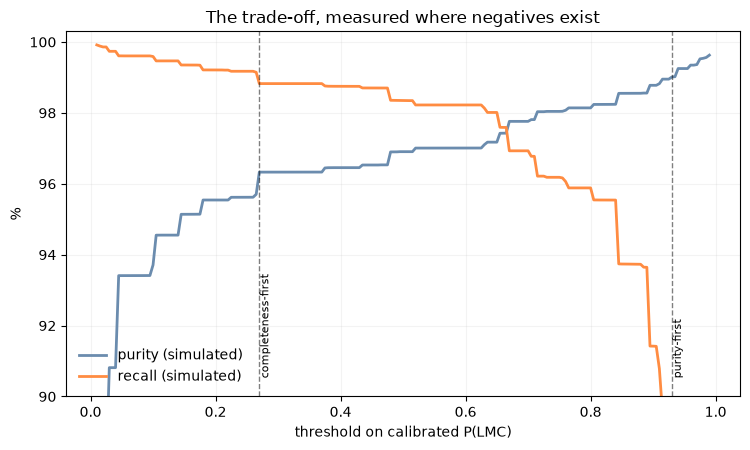

In [2]:
p_sim = calibrator.predict(
    clf.predict_proba(sim.select(FEATURES).to_numpy().astype(np.float32)[test_idx])[:, 1])
y_te = y[test_idx] == 1

grid = np.linspace(0.01, 0.99, 197)
rows = []
for t in grid:
    keep = p_sim >= t
    tp = int((keep & y_te).sum())
    rows.append({"t": t, "recall": tp / y_te.sum(), "purity": tp / max(keep.sum(), 1)})

def first_where(key, target, above=True):
    for r in rows:
        if (r[key] >= target) if above else (r[key] <= target):
            return r
    return rows[-1]

t_complete = first_where("recall", 0.99, above=False)   # lowest t still keeping >=99% recall
t_pure = first_where("purity", 0.99)                    # lowest t reaching 99% purity

OPS = {"completeness-first": t_complete, "purity-first": t_pure}
print("chosen on the SIMULATED test split:")
for name, r in OPS.items():
    print(f"  {name:<20} threshold {r['t']:.3f}   sim recall {100*r['recall']:.2f}%   "
          f"sim purity {100*r['purity']:.2f}%")

print("\nand what each costs on real DEV stars:")
for name, r in OPS.items():
    line = f"  {name:<20}"
    for cat in ("cepheid", "rrlyrae"):
        f = dev.filter(pl.col("catalogue") == cat)
        line += f"  {cat} {100*(P(f) >= r['t']).mean():5.2f}%"
    print(line)

fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.plot(grid, [100*r["purity"] for r in rows], color=MW_C, lw=2, label="purity (simulated)")
ax.plot(grid, [100*r["recall"] for r in rows], color=LMC_C, lw=2, label="recall (simulated)")
for name, r in OPS.items():
    ax.axvline(r["t"], ls="--", lw=1, color="k", alpha=0.5)
    ax.text(r["t"], 90.4, f" {name}", rotation=90, fontsize=8, va="bottom")
ax.set_xlabel("threshold on calibrated P(LMC)"); ax.set_ylabel("%")
ax.set_ylim(90, 100.3); ax.legend(frameon=False, loc="lower left"); ax.grid(alpha=0.15)
ax.set_title("The trade-off, measured where negatives exist")
plt.tight_layout(); plt.show()

## 3. Opening `lock`

Everything above was decided without these stars. This is the only place they are used, and
these are the numbers that go on the website, in the README and in the model card.

Reported with Wilson intervals, and paired with the synthetic foreground control from notebook 03
— because recall on a positives-only catalogue means nothing without something the model is
supposed to reject.

In [3]:
rng = np.random.default_rng(SEED)
is_lmc = (sim["Type"] == 1).to_numpy()
mw_pmra = sim["pmra"].to_numpy()[~is_lmc]
mw_pmdec = sim["pmdec"].to_numpy()[~is_lmc]

pick = rng.choice(len(mw_pmra), size=lock.height, replace=False)
control = lock.with_columns([
    pl.Series("pmra", mw_pmra[pick]), pl.Series("pmdec", mw_pmdec[pick]),
]).drop(["pm_total", "bp_rp", "plx_snr"]).pipe(lmc.add_derived)

p_control = P(control)
results = {}

for name, r in OPS.items():
    t = r["t"]
    print(f"\n=== {name}  (threshold {t:.3f}) ===")
    tp = 0
    for cat in ("cepheid", "rrlyrae"):
        f = lock.filter(pl.col("catalogue") == cat)
        p = P(f)
        k, n = int((p >= t).sum()), f.height
        tp += k
        results[(name, cat)] = (k, n)
        print(f"  {cat:<10} {fmt_recall(k, n)}")
    fp = int((p_control >= t).sum())
    print(f"  {'control':<10} {100*fp/len(p_control):6.2f}% accepted "
          f"({fp:,}/{len(p_control):,})   -> pseudo-purity {100*tp/(tp+fp):.2f}%")

print("\n(pseudo-purity uses synthetic negatives — it is a sanity check, not a purity measurement)")


=== completeness-first  (threshold 0.270) ===
  cepheid     96.02% [95.13, 96.76]  (2,125/2,213)
  rrlyrae     79.19% [78.41, 79.95]  (8,443/10,662)
  control      1.48% accepted (191/12,875)   -> pseudo-purity 98.22%

=== purity-first  (threshold 0.930) ===
  cepheid     73.93% [72.06, 75.71]  (1,636/2,213)
  rrlyrae     40.40% [39.47, 41.33]  (4,307/10,662)
  control      0.43% accepted (56/12,875)   -> pseudo-purity 99.07%

(pseudo-purity uses synthetic negatives — it is a sanity check, not a purity measurement)


In [4]:
# The comparison the project exists to make, on stars neither model was tuned against.
#
# Compared at each model's own operating point. Putting both at 0.5 would not be fairer:
# v1's probabilities are uncalibrated and inflated by scale_pos_weight, so 0.5 means
# something looser for v1 than it does for a calibrated v2. The final block shows that
# effect explicitly rather than hiding behind it.
_, clf_v1, F1 = models.load("v1_baseline")
t_deploy = OPS["completeness-first"]["t"]

print(f"{'':<14}{'v1 @ 0.5':>18}{'v2 @ ' + format(t_deploy, '.2f'):>18}   (lock half)")
print("-" * 66)
for cat in ("cepheid", "rrlyrae"):
    f = lock.filter(pl.col("catalogue") == cat)
    p1 = clf_v1.predict_proba(f.select(F1).to_numpy().astype(np.float32))[:, 1]
    p2 = P(f)
    k1, k2, n = int((p1 >= 0.5).sum()), int((p2 >= t_deploy).sum()), f.height
    print(f"{cat:<14}{k1/n:>17.2%}{k2/n:>18.2%}")
    print(f"{'':<14}{f'({k1:,}/{n:,})':>18}{f'({k2:,}/{n:,})':>18}")

print(f"\nfor transparency, v2 at a naive 0.5 on CALIBRATED probabilities:")
for cat in ("cepheid", "rrlyrae"):
    f = lock.filter(pl.col("catalogue") == cat)
    p2 = P(f)
    print(f"  {cat:<10} {100*(p2 >= 0.5).mean():6.2f}%")
print("  -> lower, because honest probabilities are smaller than inflated ones and 0.5")
print("     is therefore a stricter cut. This is why the threshold is chosen, not assumed.")

                        v1 @ 0.5         v2 @ 0.27   (lock half)
------------------------------------------------------------------
cepheid                  24.45%            96.02%
                     (541/2,213)     (2,125/2,213)
rrlyrae                  77.27%            79.19%
                  (8,238/10,662)    (8,443/10,662)

for transparency, v2 at a naive 0.5 on CALIBRATED probabilities:
  cepheid     95.39%
  rrlyrae     75.00%
  -> lower, because honest probabilities are smaller than inflated ones and 0.5
     is therefore a stricter cut. This is why the threshold is chosen, not assumed.


## 4. Which stars still fail?

The Cepheids are essentially solved. The RR Lyrae are not, and notebook 04 predicted why: about
one in five has a *measured* proper motion genuinely inconsistent with the LMC's bulk motion,
because at G ≈ 20 Gaia cannot measure motion finely enough to place a star in a clump a few
tenths of a mas/yr wide.

If that is right, failures should track brightness and measurement error, and **not** the
astrometric quality flags. Both halves of that prediction are checkable.

In [5]:
t = OPS["completeness-first"]["t"]
rrl_lock = lock.filter(pl.col("catalogue") == "rrlyrae")
p_rrl = P(rrl_lock)
kept = p_rrl >= t

def bin_report(values, edges, label, log_scale=False):
    print(f"\n{label:<22}{'n':>8}{'median pm error':>17}{'recall':>10}")
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (values >= lo) & (values < hi)
        if m.sum() < 80:
            continue
        print(f"  {f'{lo:g} – {hi:g}':<20}{m.sum():>8,}"
              f"{np.median(rrl_lock['pmra_error'].to_numpy()[m]):>17.3f}"
              f"{100*kept[m].mean():>9.1f}%")

bin_report(rrl_lock["phot_g_mean_mag"].to_numpy(), [16, 18.5, 19, 19.5, 20, 21.5], "G magnitude")
bin_report(rrl_lock["pmra_error"].to_numpy(), [0, 0.15, 0.25, 0.35, 0.5, 5.0], "pmra_error")
bin_report(rrl_lock["ruwe"].to_numpy(), [0, 1.1, 1.2, 1.4, 2.0, 100.0], "ruwe (quality flag)")
bin_report(rrl_lock["astrometric_excess_noise"].to_numpy(), [0, 0.01, 0.1, 0.5, 100.0],
           "excess noise")


G magnitude                  n  median pm error    recall
  18.5 – 19                409            0.206     90.0%
  19 – 19.5              8,264            0.262     81.4%
  19.5 – 20              1,787            0.342     71.2%
  20 – 21.5                202            0.679     35.1%

pmra_error                   n  median pm error    recall
  0.15 – 0.25            3,618            0.227     91.4%
  0.25 – 0.35            5,336            0.286     80.9%
  0.35 – 0.5             1,314            0.389     54.1%
  0.5 – 5                  392            0.630     27.0%

ruwe (quality flag)          n  median pm error    recall
  0 – 1.1                9,095            0.263     86.2%
  1.1 – 1.2                784            0.312     54.8%
  1.2 – 1.4                416            0.352     29.6%
  1.4 – 2                  288            0.429     15.6%

excess noise                 n  median pm error    recall
  0 – 0.01               5,602            0.259     87.7%
  0.1 – 0.

Brightness and measurement error sort the failures cleanly. Recall falls from 90% just brighter
than G = 19 to **35% beyond G = 20**, and from 91% to 27% as the proper-motion error climbs. Both
are the same axis seen twice: faint stars are measured badly.

**`ruwe` sorts them too, and that needs addressing, because notebook 04 dismissed it.** Both
results stand, because they answer different questions.

*Within* the RR Lyrae, `ruwe` does predict failure — 86% recall below 1.1, 16% above 1.4. But
read the error column beside it: median `pmra_error` climbs from 0.263 to 0.429 across exactly
those bins. `ruwe` is tracking measurement quality, which we already knew was the driver. It is a
proxy, not independent information.

*Across* populations it still points the wrong way. The Cepheids carry three times the bad-`ruwe`
rate of the RR Lyrae and are recovered at 96%. A flag that predicts failure inside one population
and anti-predicts it between two is not a cause, and cutting on it would discard good stars while
leaving the real problem untouched.

## 5. Is the residual the model's fault, or the catalogue's?

This is the question that decides whether the remaining ~20% is worth attacking.

For every RR Lyrae the model rejects, ask a question that involves no model at all: **is this
star's measured proper motion consistent with LMC membership, given its own error bars and the
LMC's real internal dispersion?**

$$\chi^2 = \frac{(\mu_\alpha^* - \mu_\alpha)^2}{\sigma_\alpha^2 + s^2}
         + \frac{(\mu_\delta^* - \mu_\delta)^2}{\sigma_\delta^2 + s^2}$$

with $s = 0.385$ mas/yr fitted in notebook 05, and $\chi^2(2)$'s 99% point at 9.21. A rejected
star with small $\chi^2$ is a **model failure** — the data supported membership and the model
missed it. A rejected star with large $\chi^2$ is one whose **measurement cannot support the
label**: either Gaia's astrometry is unreliable for it, or the variability-based membership call
is optimistic. The model is not wrong to doubt those.

In [6]:
mu_ra, mu_dec, s = pm_ref["mu_pmra"], pm_ref["mu_pmdec"], pm_ref["s_intrinsic_real_dev"]
chi2 = lmc.pm_chi2(rrl_lock["pmra"].to_numpy(), rrl_lock["pmdec"].to_numpy(),
                   rrl_lock["pmra_error"].to_numpy(), rrl_lock["pmdec_error"].to_numpy(),
                   mu_ra, mu_dec, s)
CRIT = stats.chi2(2).ppf(0.99)

missed = ~kept
consistent = chi2 <= CRIT

n_missed = int(missed.sum())
a = int((missed & consistent).sum())      # model's fault
b = int((missed & ~consistent).sum())     # data cannot support the label

print(f"s = {s:.3f} mas/yr,  chi2(2) 99% point = {CRIT:.2f}\n")
print(f"RR Lyrae in the lock half:            {rrl_lock.height:,}")
print(f"  recovered by the model:             {int(kept.sum()):,}  ({100*kept.mean():.1f}%)")
print(f"  missed:                             {n_missed:,}  ({100*missed.mean():.1f}%)\n")
print(f"Of the {n_missed:,} missed:")
print(f"  motion IS consistent with the LMC   {a:>6,}  ({100*a/n_missed:5.1f}%)  <- the model's fault")
print(f"  motion is NOT consistent            {b:>6,}  ({100*b/n_missed:5.1f}%)  <- the data cannot support it")

print(f"\nSo the model's own error rate on RR Lyrae is {100*a/rrl_lock.height:.2f}% of the catalogue,")
print(f"not {100*missed.mean():.1f}%. The rest are stars a careful astronomer would also question.")

# Sanity check the other direction: are the ACCEPTED stars mostly consistent?
print(f"\nof the {int(kept.sum()):,} accepted, {100*consistent[kept].mean():.1f}% have consistent motion")
print(f"of the {n_missed:,} missed,   {100*consistent[missed].mean():.1f}% do")

s = 0.385 mas/yr,  chi2(2) 99% point = 9.21

RR Lyrae in the lock half:            10,662
  recovered by the model:             8,443  (79.2%)
  missed:                             2,219  (20.8%)

Of the 2,219 missed:
  motion IS consistent with the LMC    1,435  ( 64.7%)  <- the model's fault
  motion is NOT consistent               784  ( 35.3%)  <- the data cannot support it

So the model's own error rate on RR Lyrae is 13.46% of the catalogue,
not 20.8%. The rest are stars a careful astronomer would also question.

of the 8,443 accepted, 100.0% have consistent motion
of the 2,219 missed,   64.7% do


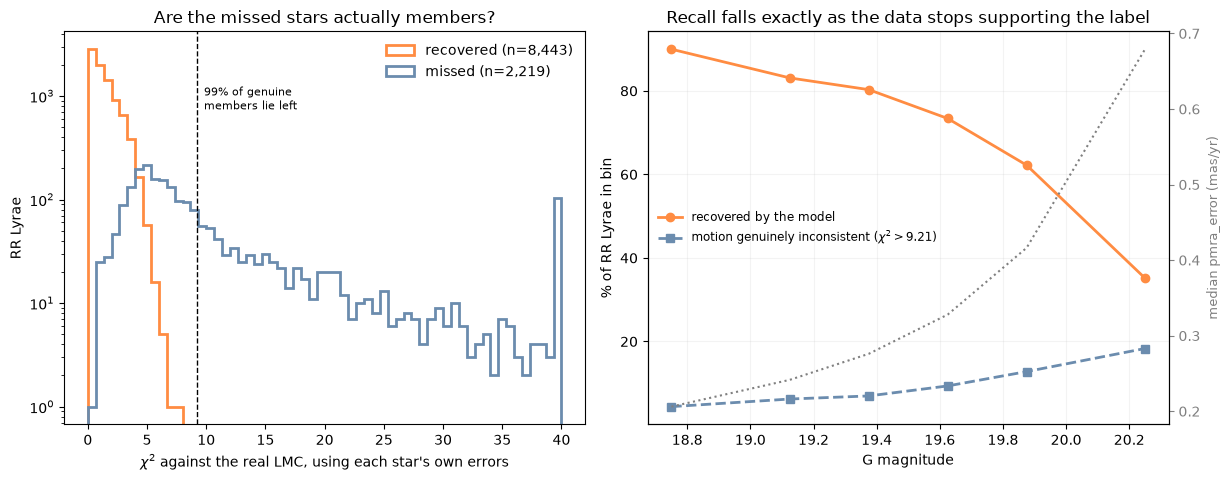

 G bin centre    recall   inconsistent   median pm error
        18.75     90.0%           4.4%             0.206
        19.12     83.1%           6.2%             0.242
        19.38     80.3%           7.0%             0.276
        19.62     73.4%           9.4%             0.328
        19.88     62.2%          12.8%             0.416
        20.25     35.1%          18.3%             0.679


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.9))

ax = axes[0]
for lab, m, c in (("recovered", kept, LMC_C), ("missed", missed, MW_C)):
    ax.hist(np.clip(chi2[m], 0, 40), bins=60, range=(0, 40), histtype="step", lw=2,
            color=c, label=f"{lab} (n={m.sum():,})")
ax.axvline(CRIT, ls="--", color="k", lw=1)
ax.text(CRIT + 0.6, ax.get_ylim()[1] * 0.25, "99% of genuine\nmembers lie left", fontsize=8)
ax.set_yscale("log")
ax.set_xlabel(r"$\chi^2$ against the real LMC, using each star's own errors")
ax.set_ylabel("RR Lyrae"); ax.legend(frameon=False)
ax.set_title("Are the missed stars actually members?")

# Recall and genuine inconsistency, against brightness. If failure is a faintness
# problem then these two curves must move together -- that is the testable claim,
# and a scatter plot cannot show it.
ax = axes[1]
gm = rrl_lock["phot_g_mean_mag"].to_numpy()
edges = np.array([18.5, 19.0, 19.25, 19.5, 19.75, 20.0, 21.5])
centres, rec, incons, err = [], [], [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (gm >= lo) & (gm < hi)
    if m.sum() < 80:
        continue
    centres.append(0.5 * (lo + min(hi, 20.5)))
    rec.append(100 * kept[m].mean())
    incons.append(100 * (~consistent[m]).mean())
    err.append(np.median(rrl_lock["pmra_error"].to_numpy()[m]))

ax.plot(centres, rec, "o-", color=LMC_C, lw=2, label="recovered by the model")
ax.plot(centres, incons, "s--", color=MW_C, lw=2,
        label=r"motion genuinely inconsistent ($\chi^2>9.21$)")
ax.set_xlabel("G magnitude"); ax.set_ylabel("% of RR Lyrae in bin")
ax.legend(frameon=False, fontsize=8.5, loc="center left"); ax.grid(alpha=0.15)
ax.set_title("Recall falls exactly as the data stops supporting the label")

ax2 = ax.twinx()
ax2.plot(centres, err, ":", color="grey", lw=1.5)
ax2.set_ylabel("median pmra_error (mas/yr)", color="grey", fontsize=9)
ax2.tick_params(axis="y", colors="grey")
plt.tight_layout(); plt.show()

print(f"{'G bin centre':>13}{'recall':>10}{'inconsistent':>15}{'median pm error':>18}")
for c, r, i, e in zip(centres, rec, incons, err):
    print(f"{c:>13.2f}{r:>9.1f}%{i:>14.1f}%{e:>18.3f}")

## 6. The model card

Everything a person needs to decide whether to use this, including the parts that argue against
it. Written here in full, and emitted as `outputs/v2_robust/card.json` so the website and the
README quote this run rather than a remembered one.

In [8]:
lock_block = {}
for name in OPS:
    lock_block[name] = {"threshold": round(float(OPS[name]["t"]), 3)}
    for cat in ("cepheid", "rrlyrae"):
        k, n = results[(name, cat)]
        lo, hi = wilson_ci(k, n)
        lock_block[name][cat] = {"k": k, "n": n, "recall": round(k/n, 4),
                                 "ci95": [round(lo, 4), round(hi, 4)]}

card = {
    "model": "v2_robust",
    "task": "Classify a Gaia source as a Large Magellanic Cloud member or Milky Way foreground.",
    "features": FEATURES,
    "training_data": {
        "source": "Gaia Object Generator simulation (LMC+MW_GOG_trainingset_frac=0.2.csv)",
        "rows": int(sim.height), "lmc_fraction": round(float(y.mean()), 4),
        "known_flaws": [
            "The simulated LMC has ZERO intrinsic proper-motion dispersion (fitted s = 0.000 "
            "mas/yr against 0.385 for the real LMC); it does not rotate.",
            "The simulated LMC is faint (median G 18.98) and contains almost no bright "
            "supergiants, so 'bright' correlates with 'foreground' in a way that is false on sky.",
            "All LMC rows fall inside one RA/Dec rectangle — a sampling-window artifact, which "
            "is why sky position is excluded.",
        ],
    },
    "validation": {
        "in_domain": "held-out 20% of the simulation, split saved with a label hash",
        "out_of_domain": ("4,485 Cepheids and 22,006 RR Lyrae confirmed as LMC members by "
                          "variability — independent of every feature the model sees"),
        "protocol": ("Real catalogues halved into dev/lock stratified on G. All design choices "
                     "made on dev; lock opened once, in notebook 06."),
    },
    "performance": {
        "simulated_held_out": json.loads((OUT / "metrics.json").read_text())["simulated_calibrated"],
        "real_sky_lock": lock_block,
    },
    "limitations": [
        "Recall only on real data: the validation catalogues contain no negatives, so purity has "
        "never been measured against real foreground stars. Every purity figure comes from the "
        "simulation.",
        "Both validation catalogues are variable stars. Performance on the LMC's ordinary "
        "stellar population is untested.",
        f"RR Lyrae fainter than G = 20 are recovered at a much lower rate; their proper-motion "
        f"errors exceed the width of the clump being searched for.",
        "Calibration was fitted on simulated data, so calibrated probabilities inherit the "
        "simulation's class balance and should be treated as approximate on real fields.",
    ],
    "do_not_use_for": [
        "Any field where the LMC is not the dominant co-moving population — the model encodes "
        "one specific bulk motion, near (1.86, 0.38) mas/yr.",
        "Surveys whose astrometric error scale differs materially from Gaia EDR3.",
        "Distance estimation. Parallax enters only as a signal-to-noise ratio, and at 50 kpc "
        "individual Gaia parallaxes are consistent with zero.",
    ],
    "supersedes": {
        "v1_baseline": ("PR-AUC 0.9992 on simulated data and 22.3% recall on real Cepheids. "
                        "Its eleven features included three measurement errors and four "
                        "magnitudes, all carrying an absolute scale the simulation sets "
                        "differently from reality."),
    },
}
(OUT / "card.json").write_text(json.dumps(card, indent=2))
print(f"wrote {OUT / 'card.json'}  ({(OUT / 'card.json').stat().st_size / 1024:.1f} KB)")

for name in OPS:
    b = lock_block[name]
    print(f"\n{name}  (threshold {b['threshold']}):")
    for cat in ("cepheid", "rrlyrae"):
        d = b[cat]
        print(f"  {cat:<10} {100*d['recall']:6.2f}%  [{100*d['ci95'][0]:.2f}, {100*d['ci95'][1]:.2f}]")

wrote ../outputs/v2_robust/card.json  (3.5 KB)

completeness-first  (threshold 0.27):
  cepheid     96.02%  [95.13, 96.76]
  rrlyrae     79.19%  [78.41, 79.95]

purity-first  (threshold 0.93):
  cepheid     73.93%  [72.06, 75.71]
  rrlyrae     40.40%  [39.47, 41.33]


## 7. What this project ended up being about

The classifier was never the hard part. XGBoost on eleven tabular columns reached PR-AUC 0.9992
in notebook 02, and that model recovers **24%** of real Cepheids.

What the six notebooks actually establish:

- **A held-out split cannot detect a wrong training distribution.** Notebook 02's methodology was
  sound — stratified split, imbalance handled with `scale_pos_weight`, recall and purity rather
  than accuracy, sky position excluded and the exclusion *demonstrated* rather than asserted.
  Every check passed. All of them asked whether the model generalises *within* its training
  distribution; none could ask whether that distribution resembles the sky.
- **The only test that mattered was data from a different source.** Cepheids and RR Lyrae
  labelled by variability — a method sharing no feature with the model.
- **Two properties of the simulation caused the failure**, and neither is visible from inside it.
  Its LMC is faint, so "bright" reads as foreground. Its LMC does not move — fitted intrinsic
  dispersion exactly 0.000 mas/yr against the real 0.385 — so any deviation beyond a star's error
  bar reads as foreground too. Real Cepheids are bright, precisely measured, and in a rotating
  galaxy: wrong on all three counts.
- **Feature importance could not have warned us.** It is a sum of gains over *training* rows. The
  three error columns held 1.6% of it and most of the failure. Adversarial validation measures the
  other property, and it takes ten lines.
- **Two plausible explanations were tested and rejected** — that trees could not extrapolate, and
  that a derived dimensionless $\chi^2$ feature would fix things. Both are in the record, because
  the reasoning that killed them is the transferable part.
- **The fix cost real in-domain performance and was still right.** v2 gives up PR-AUC in the third
  decimal place and multiplies real Cepheid recall by four.
- **The remaining failures are mostly, but not entirely, the model's.** Of the RR Lyrae it
  rejects, **35% have measured proper motions genuinely inconsistent** with LMC membership given
  their own error bars — stars a careful astronomer would also question. The model's own error
  rate on that catalogue is **13.5%**, not 20.8%. Meanwhile **100% of the stars it accepts** pass
  the same independent consistency test, which is the strongest single statement available about
  what it produces.

**Final numbers, on the sealed half, at the completeness-first operating point:**
**96.0% of real Cepheids** [95.1, 96.8] and **79.2% of real RR Lyrae** [78.4, 80.0], while
rejecting 98.5% of a synthetic foreground control.

The honest summary: this model recovers the great majority of independently confirmed LMC members;
its remaining failures concentrate in stars Gaia cannot measure precisely enough to place; and its
**purity has never been tested against real foreground stars**, because no labelled sample of them
exists here. Every purity figure in this project comes from a simulation that has now been shown
to be wrong in two specific, measured ways. That last sentence is the one a reader should carry
away, and it is in the model card for exactly that reason.